# Introducción a Jupyter para Visión Artificial, Máster en IA UMU, curso 2026/27

Este notebook introduce el uso de Jupyter Lab para realizar las prácticas de Visión Artificial 
en un entorno local Linux tipo Ubuntu o WSL. Se recomienda ejecutar el notebook con el entorno 
definido por `requirements-base.txt`.

**Nota:**
> Ciertas celdas de este notebook podrían no ejecutarse del todo correctamente en Google Colab 
  (p.e., por ciertas restricciones que introduce Colab en las máquinas virtuales subyacentes a
  la hora de acceder a ciertos URL, o por falta de algún paquete instalado, como mpld3, etc.). 
  Para ver un notebook específico de Google Colab, que además accede a ciertas funciones específicas 
  adicionales ofrecidas por dicho entorno, consultar el notebook `01_IntroColabVA.ipynb`.

## Entorno de ejecución

In [1]:
import platform
import sys

try:
    import google.colab  # type: ignore[import-not-found]
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print("Entorno:", "Google Colab" if IN_COLAB else "Jupyter local")
print("Python:", platform.python_version())

Entorno: Jupyter local
Python: 3.11.11


# Celdas ejecutables *vs* celdas `markdown`




Esto es una celda con texto explicativo, donde puede haber texto en **negrita**, *cursiva*, enlaces como [éste](https://www.um.es), ecuaciones como esta $\sum_{x=1}^{n} x^2$, etc.

También pueden hacerse listas, numeradas o no, anidadas, líneas separadoras, etc.:


1.   Primer elemento de lista numerada
2.   Segundo elemento de lista numerada

---

*   Primer elemento de lista no numerada
    * Elemento de lista a un nivel más indentado
*   Segundo elemento de lista no numerada


In [2]:
# Las celdas ejecutables, sin embargo, deben seguir sintaxis python (o, como veremos más adelante,
# también ejecutar comandos linux). Todo ello se ejecutará en la máquina subyacente (ya sea en 
# un entorno python dedicado, una máquina virtual, una máquina en la nube, etc.). Los comentarios, 
# en este caso, deben ser precedidos por '#' y llegar hasta el final de línea.
print(4+7)

11



Los niveles de título, subtítulo, etc. se indican en las celdas markdown precediendo cada título con #, ##, ###, etc. Nótese que las (sub)secciones se pueden plegar y desplegar pulsando el icono del triangulito a la izquierda del título correspondiente.

Nótese que el tipo de una celda (Code / Markdown) se puede cambiar en la barra de menú superior.

# Primer nivel

## Segundo nivel

### Tercer nivel

En este [enlace](https://colab.research.google.com/notebooks/markdown_guide.ipynb) puedes encontrar información adicional sobre `Markdown`

# Ejecución de comandos linux

Los comandos linux se ejecutan en celdas ejecutables que comienzan con el carácter "!":

In [3]:
!ls -la

total 29452
drwxrwxr-x 2 pedroe pedroe     4096 sep 18 19:21 .
drwxrwxr-x 5 pedroe pedroe     4096 sep 18 19:21 ..
-rw-rw-r-- 1 pedroe pedroe 10853735 sep 18 19:21 01_IntroColabVA.ipynb
-rw-rw-r-- 1 pedroe pedroe 10687116 sep 18 19:21 01_IntroJupyterVA.ipynb
-rw-rw-r-- 1 pedroe pedroe    17973 sep 18 19:21 colabutils.py
-rw-rw-r-- 1 pedroe pedroe    23542 sep 18 19:21 imgwc.png
-rw-rw-r-- 1 pedroe pedroe    36328 sep 18 19:21 opencv-logo.png
-rw-rw-r-- 1 pedroe pedroe   746380 sep 18 19:21 output.avi
-rw-rw-r-- 1 pedroe pedroe   381539 sep 18 19:21 output.mp4
-rw-rw-r-- 1 pedroe pedroe  7388405 sep 18 19:21 plantilla-L-15x15.mp4


Por ejemplo, las siguientes celdas comprueban si nuestro entorno de ejecución tiene o no tiene disponible una GPU, y el modelo concreto, en su caso:

In [4]:
# Obsérvese que, con ciertas limitaciones, se puede combinar bash y python en una misma celda
from shutil import which

if which("nvidia-smi"):
    !nvidia-smi          # Llamada directa a bash para ejecutar nvidia-smi
else:
    print("No hay una GPU NVIDIA disponible; estos ejemplos funcionan en CPU.")

Fri Sep 18 19:21:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.178.04             Driver Version: 580.178.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2080 Ti     Off |   00000000:01:00.0  On |                  N/A |
|  0%   57C    P0             74W /  300W |     766MiB /  11264MiB |      1%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
if which("nvidia-smi"):
    !nvidia-smi -L
else:
    print("nvidia-smi no está disponible en este equipo.")

GPU 0: NVIDIA GeForce RTX 2080 Ti (UUID: GPU-76cfac5f-ae24-9326-c31d-ed55a8d2f07d)


# Requisitos previos de un notebook

Habitualmente un notebook necesitará unos requisitos previos. Por ejemplo:

* Scripts auxiliares de python, con funciones de apoyo, etc.
* Ficheros con datos de entrada (imágenes, vídeos).
* Instalación de paquetes no instalados por defecto en la máquina virtual subyacente.
* Etc.

He aquí algunos ejemplos:

In [6]:
from pathlib import Path
from shutil import copyfileobj, which
from urllib.request import urlopen

def download_if_missing(url, destination, minimum_size=1):
    destination = Path(destination)
    if destination.is_file() and destination.stat().st_size >= minimum_size:
        print(f"Ya existe: {destination}")
        return destination

    temporary = destination.with_suffix(destination.suffix + ".part")
    print(f"Descargando {url}")
    with urlopen(url, timeout=60) as response, temporary.open("wb") as output:
        copyfileobj(response, output)
    if temporary.stat().st_size < minimum_size:
        raise RuntimeError(f"Descarga incompleta desde {url}")
    temporary.replace(destination)
    print(f"Guardado: {destination} ({destination.stat().st_size} bytes)")
    return destination

OPENCV_LOGO_URL = "https://raw.githubusercontent.com/opencv/opencv/4.x/doc/opencv-logo.png"
VIDEO_URL = "https://ditec.um.es/~pedroe/plantilla-L-15x15.mp4"

download_if_missing(OPENCV_LOGO_URL, "opencv-logo.png", minimum_size=1_000)

if which("ffmpeg") is None:
    raise RuntimeError(
        "No se encuentra el ejecutable FFmpeg. Puedes instalarlo manualmente con 'sudo apt install ffmpeg'"
    )
print("FFmpeg disponible")

Ya existe: opencv-logo.png
FFmpeg disponible


La celda anterior descarga la imagen únicamente si no existe y comprueba que
el ejecutable FFmpeg está disponible. Las bibliotecas de Python se instalan una
sola vez desde `requirements-base.txt`, de forma previa a la ejecución del notebook.

In [7]:
import subprocess

ffmpeg_version = subprocess.run(
    ["ffmpeg", "-version"], check=True, capture_output=True, text=True
).stdout.splitlines()[0]
print(ffmpeg_version)

ffmpeg version 6.1.1-3ubuntu5 Copyright (c) 2000-2023 the FFmpeg developers


Por otro lado, nuestro notebook se apoyará siempre en una serie de módulos importados de python, que habitualmente conviene colocar juntos en una celda cerca del principio. Por ejemplo:

In [8]:
import cv2
import numpy as np
import ipywidgets
import matplotlib.pyplot as plt

Siempre podemos consultar la versión instalada de un paquete consultando su campo `__version__`:

In [9]:
print(cv2.__version__)
print(np.__version__)

4.14.0
2.4.6


# Utilidades genéricas interesantes para la asignatura

## Cargar una imagen y mostrarla en el notebook

Si la imagen ya está en la máquina virtual (p.e., porque una celda anterior del notebook ya la descargó), lo más inmediato es usar `cv2.imread` y `plt.imshow`:

**Nota**: El punto y coma (;) al final de la última instrucción sirve para impedir que salga el (normalmente inútil) mensaje de texto _<matplotlib.image.AxesImage at ...>_ asociado a la ejecución de `plt.imshow`.

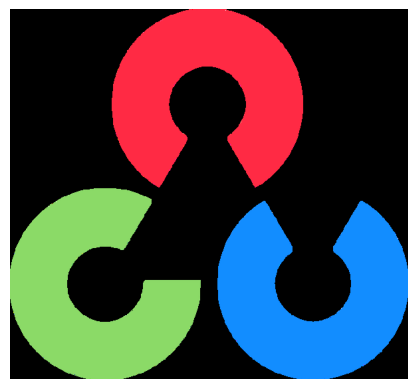

In [10]:
img_bgr = cv2.imread("opencv-logo.png")
if img_bgr is None:
    raise RuntimeError("No se ha podido leer opencv-logo.png")
img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.axis("off");

Si se desea, interactivamente, subir una imagen desde nuestro ordenador para que sea procesada en el notebook, podemos emplear un código como el siguiente:


**Nota**: Las siguientes celdas no mostrarán ninguna imagen hasta que se pinche el botón _"Upload"_ y se elija un archivo de imagen a subir al notebook.

In [11]:
from ipywidgets import FileUpload, Button, Output
from IPython.display import display

upload_widget = FileUpload(accept='image/*', multiple=False)
output = Output()

uploaded_img_filename = None
def on_upload_change(change):
    # Obtener el archivo subido
    for file_info in upload_widget.value:
        # Guardar el archivo en la máquina remota
        with open(file_info['name'], 'wb') as f:
            f.write(file_info['content'])
        with output:
            print(f"Archivo {file_info['name']} subido y guardado con éxito.")
        global uploaded_img_filename
        uploaded_img_filename = file_info['name']

# Conectar el evento del widget al manejador
upload_widget.observe(on_upload_change, names='value')

# Mostrar el widget
display(upload_widget,output)

FileUpload(value=(), accept='image/*', description='Upload')

Output()

In [12]:
if uploaded_img_filename is not None:
    imgupl = cv2.imread(uploaded_img_filename)
    plt.imshow(cv2.cvtColor(imgupl, cv2.COLOR_BGR2RGB));


Las imágenes son arrays de numpy (tensores de 3 dimensiones: filas, columnas, canales RGB), que pueden naturalmente ser modificadas y guardadas posteriormente en otro archivo.

He aquí un ejemplo para invertir los colores de los tres canales de la imagen del logo anterior:

(556, 599, 3)
(556, 599, 3)


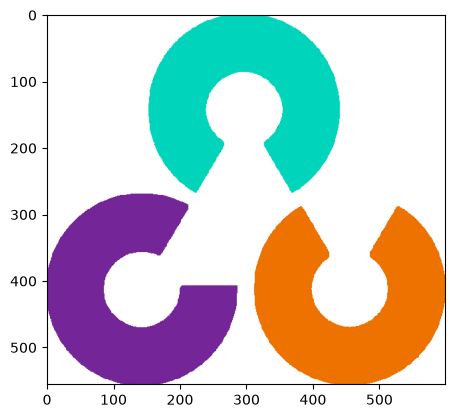

In [13]:
print(img.shape)
imginv = 255 - img
print(img.shape)
cv2.imwrite("opencv-logo-inv.png",cv2.cvtColor(imginv, cv2.COLOR_BGR2RGB))
plt.imshow(imginv);

## Lectura, visionado y escritura de vídeos

Descarguemos en primer lugar un vídeo de prueba, en formato `.mp4`:

In [14]:
download_if_missing(VIDEO_URL, "plantilla-L-15x15.mp4", minimum_size=1_000_000)

Ya existe: plantilla-L-15x15.mp4


PosixPath('plantilla-L-15x15.mp4')

(Si el vídeo original no estuviese con el codec adecuado y en formato .mp4, siempre podríamos emplear un comando como el siguiente para convertir a un formato válido, legible con la librería opencv, prácticamente cualquier vídeo de entrada:)

In [15]:
# ! ffmpeg -y -i inputvideo.avi -vcodec h264 -acodec mp2 outputvideo.mp4;

La siguiente función nos valdrá para mostrar el vídeo en el propio _notebook_:

In [16]:
from IPython.display import HTML
from base64 import b64encode

def play_video(videofilename):
    mp4 = open(videofilename,'rb').read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    return HTML("""
    <video width=400 controls>
      <source src="%s" type="video/mp4">
    </video>
    """ % data_url)

He aquí un ejemplo de su uso. Obsérvese que, a pesar de que el consumo de CPU es mínimo, la celda puede tardar un tiempo en ejecutarse, especialmente si estamos ejecutando una celda como esta en el cluster de la UMU o en Google Colab, ya que en este caso deberían descargarse los datos del vídeo desde allí hasta nuestra máquina local, donde lo estamos visualizando:

In [17]:
%%time
play_video('plantilla-L-15x15.mp4')

CPU times: user 15.6 ms, sys: 11.8 ms, total: 27.5 ms
Wall time: 27.5 ms


Veamos ahora cómo leer un vídeo frame a frame, realizar con él algún tipo de procesamiento, y salvar un vídeo de salida:

In [18]:
%%time
# Abrimos el vídeo y obtenemos un frame para conocer su resolución.
videoreader = cv2.VideoCapture("plantilla-L-15x15.mp4")
grabbed, frame = videoreader.read()
videoreader.release()
if not grabbed:
    raise RuntimeError("No se ha podido leer plantilla-L-15x15.mp4")
videoshape = frame.shape

# Abrimos la fuente de vídeo y el vídeo de salida.
videoreader = cv2.VideoCapture("plantilla-L-15x15.mp4")
videowriter = cv2.VideoWriter(
    "output.avi",
    cv2.VideoWriter_fourcc(*"mp4v"),
    30,
    (videoshape[1], videoshape[0]),
    True,
)
if not videowriter.isOpened():
    videoreader.release()
    raise RuntimeError("OpenCV no ha podido crear output.avi")

# Grabamos invertidos los primeros 150 frames disponibles.
i = 0
while i < 150:
    grabbed, frame = videoreader.read()
    if not grabbed:
        break
    videowriter.write(255 - frame)
    i += 1

videowriter.release()
videoreader.release()
print(f"Frames procesados: {i}")

Frames procesados: 150
CPU times: user 377 ms, sys: 34.6 ms, total: 412 ms
Wall time: 233 ms


Antes de mostrar el vídeo generado en el interfaz, hay que convertirlo al formato `.mp4` compatible con HTML5 (empleamos para ello el comando `ffmpeg`):

In [19]:
%%time
import subprocess

subprocess.run(
    [
        "ffmpeg", "-hide_banner", "-loglevel", "error",
        "-y", "-i", "output.avi", "-an",
        "-vcodec", "libx264", "-pix_fmt", "yuv420p", "output.mp4",
    ],
    check=True,
)

CPU times: user 406 μs, sys: 138 μs, total: 544 μs
Wall time: 452 ms


CompletedProcess(args=['ffmpeg', '-hide_banner', '-loglevel', 'error', '-y', '-i', 'output.avi', '-an', '-vcodec', 'libx264', '-pix_fmt', 'yuv420p', 'output.mp4'], returncode=0)

In [20]:
play_video('output.mp4')

## Matplotlib interactivo con MPLD 3

Si queremos que los gráficos generados con Matplotlib posean interactividad
(zoom, desplazamiento, etc.), podemos usar `mpld3`. El paquete ya forma parte
de `requirements-base.txt`.

In [21]:
from importlib.metadata import version

print("mpld3", version("mpld3"))

mpld3 0.5.12


Una vez instalado, la forma más sencilla de usarlo es embebiendo los gráficos matplotlib generados entre las funciones `enable_notebook` y `disable_notebook`:

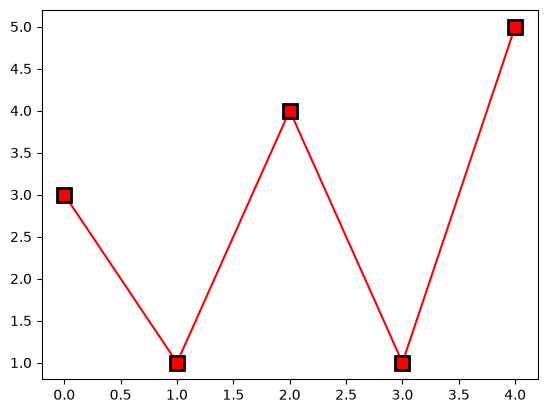

In [22]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import mpld3

mpld3.enable_notebook()
plt.plot([3,1,4,1,5], 'rs-', mec='k', mew=2, ms=10)
plt.show()
mpld3.disable_notebook()

_(Nótese que ahora puede realizarse la interacción mediante los iconos mostrados abajo a la izquierda)_

La siguiente celda muestra la diferencia entre el renderizado con interacción (imagen superior) y sin interacción (imagen inferior), usando esta vez como ejemplo una imagen mostrada mediante matplotlib:

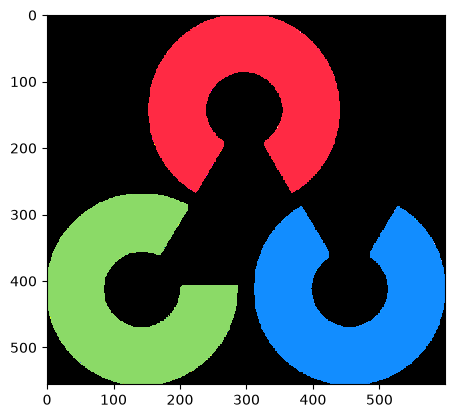

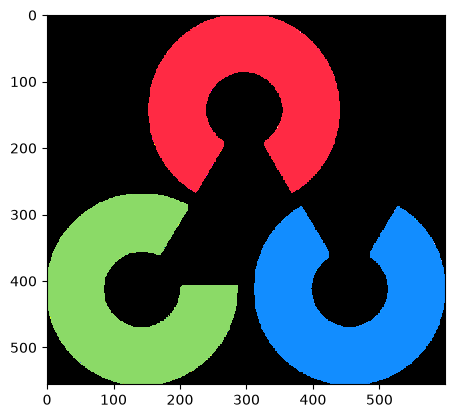

In [23]:
# Con interacción tras renderizado:
mpld3.enable_notebook()
plt.imshow(img, interpolation='nearest') 
plt.show()
# Nota: interpolación "nearest", p.e., no funciona con mpld3; existen ciertas limitaciones 
# en la funcionalidad implementada de matplotlib en mpld3, aunque tampoco demasiadas.

# Sin interacción tras renderizado:
mpld3.disable_notebook()
plt.imshow(img, interpolation='nearest')
plt.show()

## Interacción del usuario mediante Ipywidgets


La alternativa más conocida para esto es la ofrecida por el módulo `ipywidgets`, que es también bastante flexible. Una introducción rápida al uso de los mismos se puede encontrar [aquí](https://colab.research.google.com/github/jupyter-widgets/ipywidgets/blob/master/docs/source/examples/Using%20Interact.ipynb). Aunque, en principio, basta saber que la función `interact` del mencionado módulo permite llamar de forma continua a una función cualquiera, que imprima y/o muestre unos resultados gráficamente en el _notebook_, pasándole en todo momento los parámetros cuyos controles visuales (_widgets_) se deseen. En realidad, la función sólo se ejecuta cuando cambian los mismos.

He aquí un primer ejemplo, con una imagen cuyo brillo controlamos con un slider que toma valores entre 0.0 y 1.0:

In [24]:
from ipywidgets import interact, FloatSlider, fixed
import scipy.linalg

def plot_image(img,alpha):
  mpld3.disable_notebook()
  plt.imshow((alpha * img).astype("uint8"))
  plt.show()

interact(plot_image, img=fixed(img), alpha=(0.0, 1.0, 0.05));

interactive(children=(FloatSlider(value=0.5, description='alpha', max=1.0, step=0.05), Output()), _dom_classes…

_(Nótese que, en la celda anterior, se debe usar_ `fixed(...)` _para todo parámetro de la función para el que NO se desee un_ widget _de interacción)_.

## Interacción mediante clicks del ratón

También podemos usar ipywidgets para esto:

In [25]:
button = Button(description="Click Me!")
output = Output()

display(button, output)

def on_button_clicked(b):
    with output:
        print("Button clicked.")

button.on_click(on_button_clicked)

Button(description='Click Me!', style=ButtonStyle())

Output()

## Ejemplo de ROI dinámico

Otro ejemplo, algo más completo, que incluye en este caso una _region of interest_ (ROI) dinámica, definida por el usuario:

In [26]:
from ipywidgets import IntRangeSlider

def plot_image(img,roih,roiv,alpha):
  global roi
  roi=(roih,roiv)
  imgout = img.copy()
  imgout[roih[0]:roih[1]+1,roiv[0]:roiv[1]+1,:] = (img[roih[0]:roih[1]+1,roiv[0]:roiv[1]+1,:]*alpha).astype('uint8')
  fig,ax = plt.subplots(figsize=(6,8))
  ax.imshow(imgout, interpolation='nearest')
  plt.show()

H,W = tuple(img.shape[:2])
interact(plot_image, img=fixed(img),
         roih=IntRangeSlider(value=[H//3,2*H//3],min=0,max=H-1,orientation='horizontal'),
         roiv=IntRangeSlider(value=[W//3,2*W//3],min=0,max=W-1,orientation='horizontal'),
         alpha=FloatSlider(value=0.5,min=0.0,max=1.0,orientation='horizontal'));


interactive(children=(IntRangeSlider(value=(185, 370), description='roih', max=555), IntRangeSlider(value=(199…

## Movernos por una secuencia de imágenes resultado de procesar un vídeo

Imaginemos que tenemos una secuencia de vídeo que queremos procesar, _frame_ a _frame_, y queremos después movernos por las imágenes resultado del procesamiento para inspeccionar visualmente los resultados.

Una forma sencilla de hacer esto en un notebook es la siguiente:
1. Se procesa (en modo _batch_) la secuencia, generando toda la salida (visual y/o de texto) y guardando los datos resultado correspondientes en una lista de python, con un elemento por cada frame procesado.
2. Una vez se ha realizado todo el procesamiento, se monta una estructura tipo `interact` como las anteriores, con un sencillo _slider_ para poder movernos por ella al frame deseado.
De esta manera, podremos acceder cómoda y dinámicamente a mostrar el frame deseado en cada momento.

Por ejemplo, para esta sencilla función de procesamiento de imagen:

In [27]:
# Función de procesamiento de ejemplo. En este caso dicho "procesamiento" es
# extremadamente simple, para mantener el ejemplo sencillo; pero, obviamente,
# podría aplicarse en este punto cualquier procesamiento más complicado,
# que dibujase cualquier otro tipo de salida visual y/o de texto sobre la imagen):
def process_image(img, alpha):
  # Simplemente atenúa la región central de la imagen, usando el parámetro alpha:
  H,W = tuple(img.shape[:2])
  roih, roiv = [H//3,2*H//3], [W//3,2*W//3]
  imgout = img.copy()
  imgout[roih[0]:roih[1]+1,roiv[0]:roiv[1]+1,:] = \
    (img[roih[0]:roih[1]+1,roiv[0]:roiv[1]+1,:]*alpha).astype('uint8')
  return (imgout, alpha)

Haríamos lo siguiente, para inspeccionar sus resultados sobre una secuencia de vídeo:

In [28]:
# Apertura de fuente de vídeo:
videoreader = cv2.VideoCapture("plantilla-L-15x15.mp4")

# Leemos los primeros 150 frames del vídeo de entrada, y para cada uno de ellos,
# atenuamos la región central según un parámetro alpha:
i = 0
louts = []                   # Lista donde se guardarán los resultados
alpha, signinc = 0.25, +1    # Valores iniciales para el procesamiento
while True:
  (grabbed, img) = videoreader.read()
  if not grabbed or i==150: # Sólo 150 primeros frames
    break
  else:
    # El parámetro alpha oscilará durante la secuencia:
    alpha += signinc*0.01
    if alpha >= 0.75 or alpha <= 0.25:
      signinc = -signinc

    # Realizamos el procesamiento:
    (imgout, alpha) = process_image(img, alpha)

    # Añadimos ahora a la lista de resultados, la imagen resultante, junto con la
    # información textual que queramos mostrar (en este caso, simplemente el
    # valor actual de alpha):
    louts.append((imgout,alpha))
  # Siguiente frame:
  i += 1

La lista `louts` contiene ahora los resultados, que procedemos a mostrar con la técnica descrita, usando `interact` con un _slider_ para movernos por los _frames_.

In [29]:
from ipywidgets import IntSlider

def plot_image(louts, framepos):
  plt.imshow(cv2.cvtColor(louts[framepos][0], cv2.COLOR_BGR2RGB))
  print(f'alpha = {louts[framepos][1]:.2f}')
  plt.show() # Terminar siempre con plt.show()

interact(plot_image, louts=fixed(louts),
         framepos=IntSlider(value=0,min=0,max=len(louts)-1,orientation='horizontal'));

interactive(children=(IntSlider(value=0, description='framepos', max=149), Output()), _dom_classes=('widget-in…

# Ejercicios interesantes para familiarizarnos con el entorno



1. Descargar una imagen cualquiera de la web usando wget con su URL, y mostrarla en el notebook. No olvidar que el orden de los canales en OpenCV es BGR, y en matplotlib RGB, por lo que podría hacer falta usar la función `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)`
2. Mostrar los datos crudos (array 3D de tipo uint8) de la imagen descargada.
3. Mostrar la forma (dimensiones) del array, usando el método `.shape` sobre la misma.
4. Usando el `slicing` de `numpy`, construir y mostrar gráficamente una imagen que contenga:
 * Sólo la mitad izquierda de la imagen.
 * Sólo la mitad superior de la imagen.
 * Sólo el canal rojo de la imagen completa RGB.
 (Usar la opción cmap='gray' con plt.imshow para evitar que se use un mapa de color diferente al de las meras tonalidades de gris).
5. Usando de nuevo el `slicing`, construir una imagen equivalente a la descargada, pero a mitad de resolución (esto es, con dimensiones $(height/2,width/2,3)$)
6. Construir y mostrar un vídeo igual al original plantilla-L-15x15.mp4, pero con la mitad de resolución.
7. Generar una lista con los 150 primeros frames del vídeo anterior, en la que en cada imagen aparezca un cuadro rojo de tamaño 30x30 píxeles y cuya esquina superior izquierda sea $(x,y) = (10+i,10)$, para cada frame $0 ≤ i < 150$.
8. Usar entonces la función `interact` para que podamos movernos con un slider entre las posiciones 0 y 149 por la lista de imágenes generada.

**Nota**: Los notebooks `IntroNumpyHOML.ipynb` y `IntroMatplotlibHOML.ipynb` contienen una buena cantidad de ejemplos de usos más avanzados de `numpy` y `matplotlib`, por lo que resulta recomendable echarles un vistazo detallado, y coger de ellos ideas para poder realizar posibles procesamientos adicionales elementales sobre imágenes de prueba.